In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [32]:
seeds = 30
agg_all = []
agg_incorrect = []
agg_correct = []
for seed in range(seeds):
        data = np.load(f'./lambda_shifts/policy_lambda_shifts_s{seed}.npz',
                allow_pickle=True)

        all_lambdas = data['all_lambdas']
        incorrect_lambdas = data['incorrect_lambdas']
        correct_lambdas = data['correct_lambdas']

        # print(all_lambdas.shape, incorrect_lambdas.shape, correct_lambdas.shape)

        agg_all.append(all_lambdas)
        agg_incorrect.append(incorrect_lambdas)
        agg_correct.append(correct_lambdas)

# flatten 
agg_all = np.concatenate(agg_all,axis=0)
agg_incorrect = np.concatenate(agg_incorrect,axis=0)
agg_correct = np.concatenate(agg_correct,axis=0)

print(agg_all.shape, agg_incorrect.shape, agg_correct.shape)

(29970, 777) (13753, 777) (13979, 777)


0 1 2.828908197416331 0.0047347835991436125
0 2 -3.0759034064582793 0.002137689427241141
1 2 -4.978378517801089 7.658330875572897e-07
[['consecutive', 29970, 'decreased', 13753, 2.828908197416331, 0.0047347835991436125], ['consecutive', 29970, 'increased', 13979, -3.0759034064582793, 0.002137689427241141], ['decreased', 13753, 'increased', 13979, -4.978378517801089, 7.658330875572897e-07]]


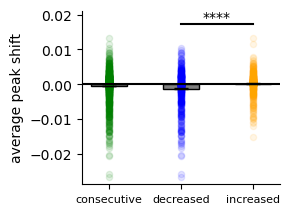

In [34]:
pvals = []
plt.figure(figsize=(3, 2.25), facecolor='white')

data = [np.mean(all_lambdas,axis=1), np.mean(incorrect_lambdas,axis=1), np.mean(correct_lambdas,axis=1)]
# Calculate statistics
means = [np.mean(d) for d in data]
sems = [stats.sem(d) for d in data]

agg = [agg_all, agg_incorrect, agg_correct]
labels = ['consecutive', 'decreased', 'increased']
x_pos = np.arange(len(labels))
outlier_colors = ['green', 'blue', 'orange']

# Create bars with error bars
bars = plt.bar(labels, means, width=0.5,
            color='gray',
            edgecolor='black',
            linewidth=1,
            yerr=sems,
            capsize=5)
# plt.errorbar(labels, means, yerr=sems, fmt='o', capsize=5)

# # Add mean lines on top of bars
# for i, mean in enumerate(means):
#     plt.plot([x_pos[i]-0.3, x_pos[i]+0.3], [mean, mean],
#              color='black', linewidth=2)

# Add outliers with original colors
for i, d in enumerate(data):
    # Jitter x-position for visibility
    x_jittered = np.random.normal(x_pos[i], 0.00, size=len(d))
    plt.scatter(x_jittered, d,
                color=outlier_colors[i],
                alpha=0.1,
                edgecolors=outlier_colors[i],
                s=20)

plt.ylabel('average peak shift')
plt.xticks(x_pos, labels, fontsize=8)
plt.axhline(y=0, color='black')

# Keep your original significance testing code
comparisons = [(0, 1), (0, 2), (1, 2)]
y_max = max([np.max(d) for d in data])  # Find maximum y-value
bar_levels = [y_max * 1.1, y_max * 1.2, y_max * 1.3]

for (i, j), level in zip(comparisons, bar_levels):
    t_stat, p_val = stats.ttest_ind(data[i], data[j])
    print(i,j, t_stat, p_val)
    pvals.append([labels[i], agg[i].shape[0], labels[j], agg[j].shape[0], t_stat, p_val])

    if p_val < 0.001:
        symbol = '*' * min(4, int(-np.log10(p_val)) + 1)
        plt.plot([x_pos[i], x_pos[j]], [level, level], color='black')
        plt.text((x_pos[i]+x_pos[j])/2, level, symbol,
                ha='center', va='bottom', fontsize=10)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.ylim(top=y_max * 1.6)
plt.tight_layout()
plt.savefig(f'./lambda_shifts/policy_seeds{seeds}.pdf', bbox_inches='tight')

print(pvals)

# save pvals as csv
np.savetxt(f'./lambda_shifts/policy_seeds{seeds}_pvals_1000N_{agg_all.shape[1]}r.csv', pvals, delimiter=',', fmt='%s', header='Group1,N1,Group2,N2,t-stat,p-value')